# **House Price Prediction**
### This project utilizes the "House Price Prediction in dollar – Tehran (Spring-1400)" dataset, which was originally crawled from Divar.ir and made available on Kaggle by Soheil Tehranipour.

## 1. Imports

In [61]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,ExtraTreesRegressor, BaggingRegressor)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import time
from catboost import CatBoostRegressor

import joblib
import os

import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [62]:
df = pd.read_csv('../tehranhouses.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (3479, 7)


,Area,Room,Parking,Warehouse,Elevator,Address,Price(USD)
0,63,1,True,True,True,Shahran,61666.67
1,60,1,True,True,True,Shahran,61666.67
2,79,2,True,True,True,Pardis,18333.33
3,95,2,True,True,True,Shahrake Qods,30083.33
4,123,2,True,True,True,Shahrake Gharb,233333.33


In [63]:
# Drop Toman Price
if 'price' in df.columns:
    df = df.drop(columns=['price'])

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3479 non-null   object 
 1   Room        3479 non-null   int64  
 2   Parking     3479 non-null   bool   
 3   Warehouse   3479 non-null   bool   
 4   Elevator    3479 non-null   bool   
 5   Address     3456 non-null   object 
 6   Price(USD)  3479 non-null   float64
dtypes: bool(3), float64(1), int64(1), object(2)
memory usage: 119.0+ KB


In [65]:
df.describe(include='all')

,Area,Room,Parking,Warehouse,Elevator,Address,Price(USD)
count,3479,3479.000000,3479,3479,3479,3456,3.479000e+03
unique,243,NaN,2,2,2,192,NaN
top,75,NaN,True,True,True,Punak,NaN
freq,111,NaN,2950,3182,2739,161,NaN
mean,NaN,2.079908,NaN,NaN,NaN,NaN,1.786341e+05
std,NaN,0.758275,NaN,NaN,NaN,NaN,2.699978e+05
min,NaN,0.000000,NaN,NaN,NaN,NaN,1.200000e+02
25%,NaN,2.000000,NaN,NaN,NaN,NaN,4.727500e+04
50%,NaN,2.000000,NaN,NaN,NaN,NaN,9.666667e+04
75%,NaN,2.000000,NaN,NaN,NaN,NaN,2.000000e+05


## 3. Data Cleaning

### 3.1 Fix Types

In [66]:
# Area stored as string
df['Area'] = pd.to_numeric(df['Area'].str.replace(',', ''), errors='coerce')

# Boolean amenity columns change to int(0/1)
bool_cols = ['Parking', 'Warehouse', 'Elevator']
df[bool_cols] = df[bool_cols].astype(int)

df.dtypes

Area            int64
Room            int64
Parking         int64
Warehouse       int64
Elevator        int64
Address        object
Price(USD)    float64
dtype: object

### 3.2 Drop Missing Values

In [67]:
print(f"Missing values before drop:\n{df.isnull().sum()}\n")
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Shape after drop: {df.shape}")

Missing values before drop:
Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price(USD)     0
dtype: int64

Shape after drop: (3456, 7)


## 4. Exploratory Data Analysis

### 4.1 Target Distributions

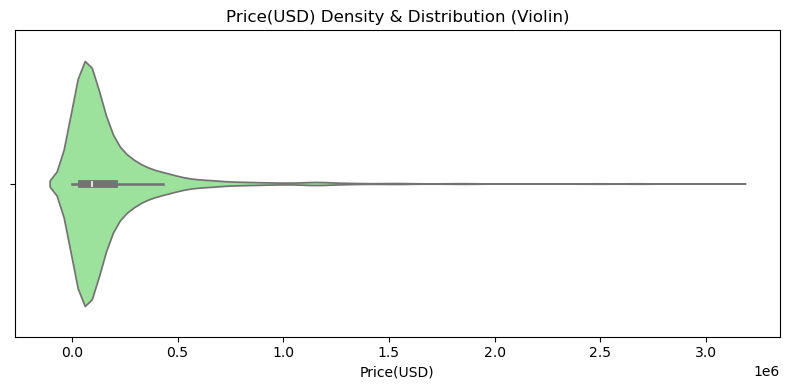

In [68]:
plt.figure(figsize=(8, 4))
sns.violinplot(data=df, x='Price(USD)', color='lightgreen')

plt.title('Price(USD) Density & Distribution (Violin)')
plt.tight_layout()
plt.show()

### 4.2 Correlation Heatmap

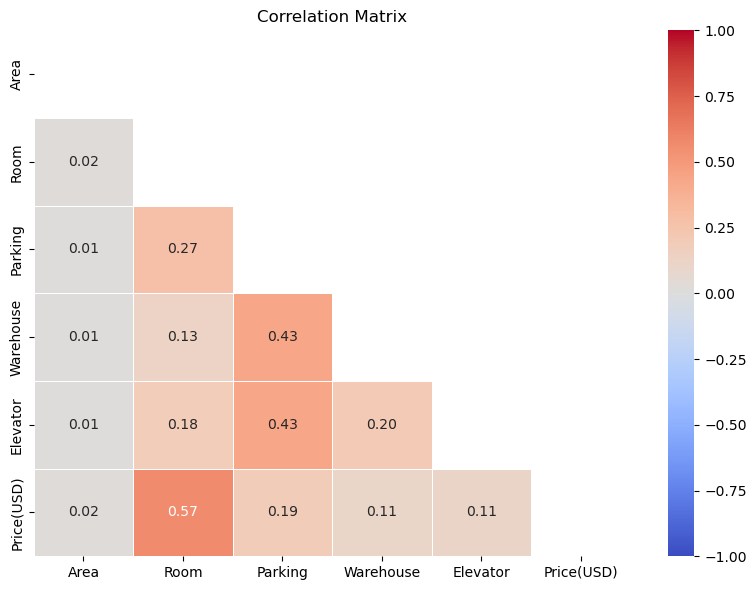

In [69]:
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### 4.3 Amenity Distributions (Parking / Warehouse / Elevator)

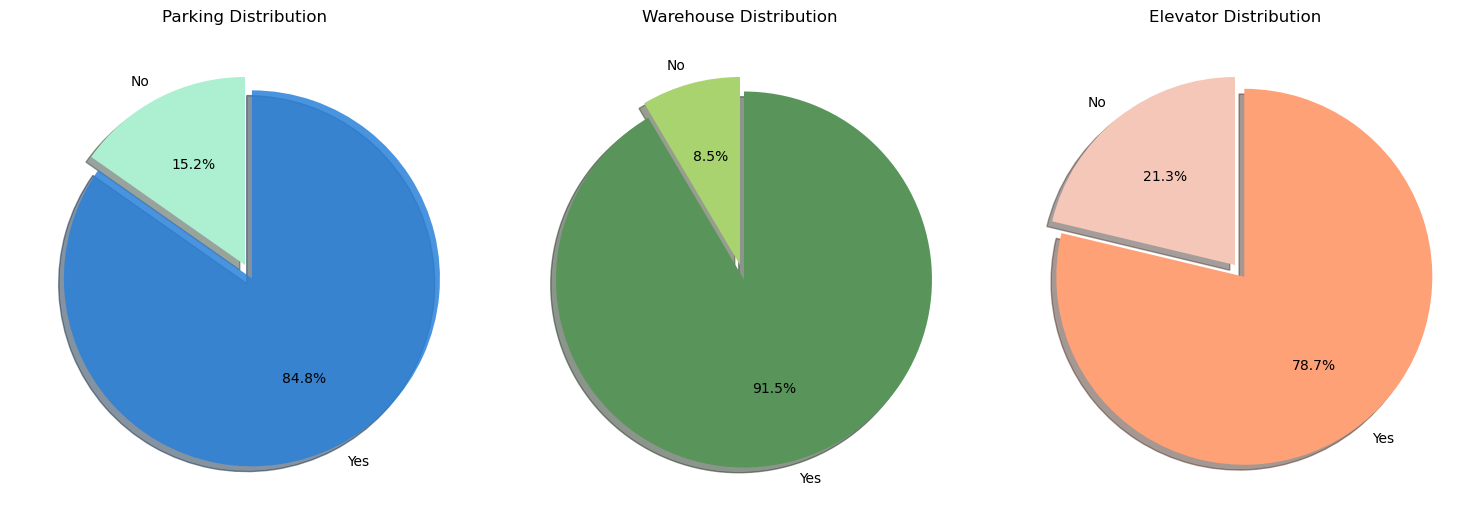

In [70]:
colors_list = [['#ADEFD1FF',"#2981DAD8"], ["#A9D36FFF","#59945A"], ['#F5C7B8FF','#FFA177FF']]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, colors in zip(axes, bool_cols, colors_list):
    counts = df[col].value_counts().sort_index()
    ax.pie(counts, labels=['No','Yes'], colors=colors,
           autopct='%1.1f%%', startangle=90, shadow=True, explode=[0, 0.08])
    ax.set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

## 5. Outlier Detection & Removal

### 5.1 Feature Skewness & Boxplots

Skewness:
 Area          43.827765
Price(USD)     4.765172
Room           0.623938
Elevator      -1.404947
Parking       -1.934179
Warehouse     -2.975864
dtype: float64


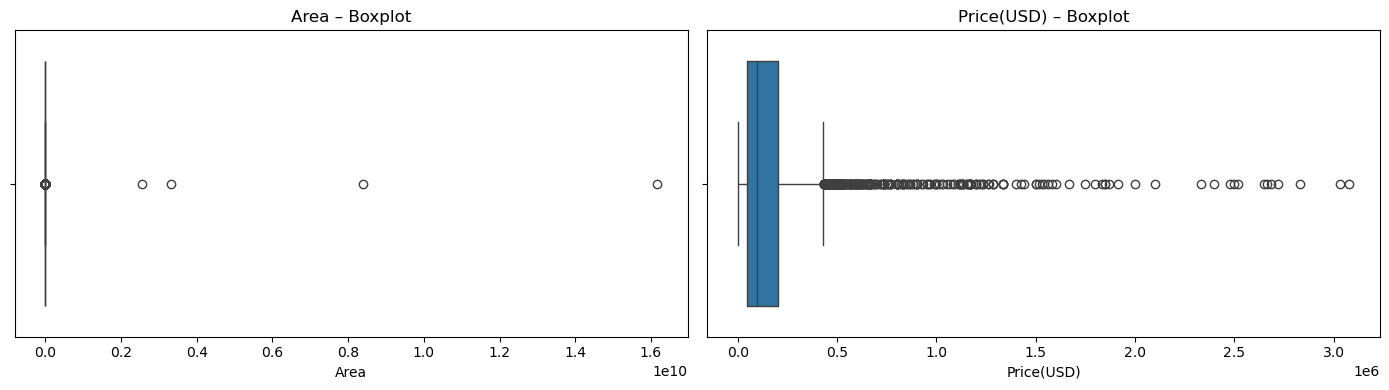

In [71]:
print("Skewness:\n", df.skew(numeric_only=True).sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['Area', 'Price(USD)']):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f'{col} – Boxplot')
plt.tight_layout()
plt.show()

### 5.2 IQR Bounds (reference)

In [72]:
def iqr_bounds(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

for col in ['Area', 'Price(USD)']:
    lo, hi = iqr_bounds(df[col])
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col}: lower={lo:,.1f}  upper={hi:,.1f}  outliers={n_out}")

Area: lower=-9.0  upper=199.0  outliers=237
Price(USD): lower=-181,666.7  upper=429,000.0  outliers=310


### 5.3 Domain-Knowledge Thresholds & Filter

In [73]:
BOUNDS = {
    'Area':       (20, 1000),
    'Price(USD)': (1_000, 10_000_000),
    'Room':       (0, 6),
}

# Create the valid data mask
mask = pd.concat(
    [df[col].between(lo, hi) for col, (lo, hi) in BOUNDS.items()], axis=1
).all(axis=1)

# Create a dataframe of ONLY the dropped rows
dropped_df = df[~mask]

print(f"Rows removed: {dropped_df.shape[0]}  |  {df.shape[0]} → {mask.sum()}")
print("\nSamples of Dropped Data:")

# Display the dropped rows 
if not dropped_df.empty:
    print(dropped_df[['Area', 'Price(USD)', 'Room']].head(20)) # Shows the first 20 dropped rows
else:
    print("No rows were dropped.")

# Finally, apply the filter to df
df = df[mask].reset_index(drop=True)
df.shape

Rows removed: 6  |  3456 → 3450

Samples of Dropped Data:
             Area  Price(USD)  Room
135           160      120.00     1
569    3310000000   110333.33     2
706   16160000000   538666.67     3
1598   8400000000   290000.00     2
2161         3600   324000.00     2
2788   2550000000    85000.00     2


(3450, 7)

### 5.4 Distributions After Cleaning

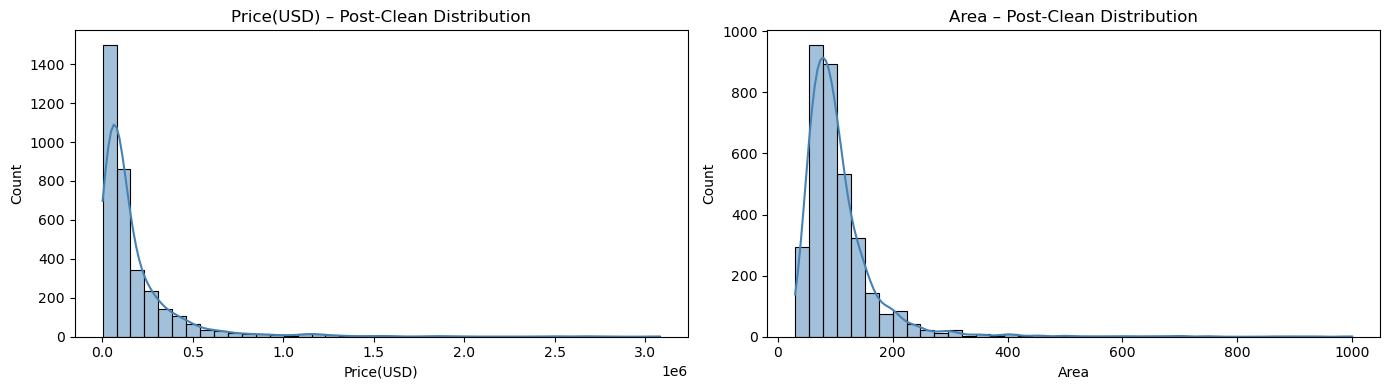

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['Price(USD)', 'Area']):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'{col} – Post-Clean Distribution')
plt.tight_layout()
plt.show()

### 5.5 Price vs. Area (by Room Count)

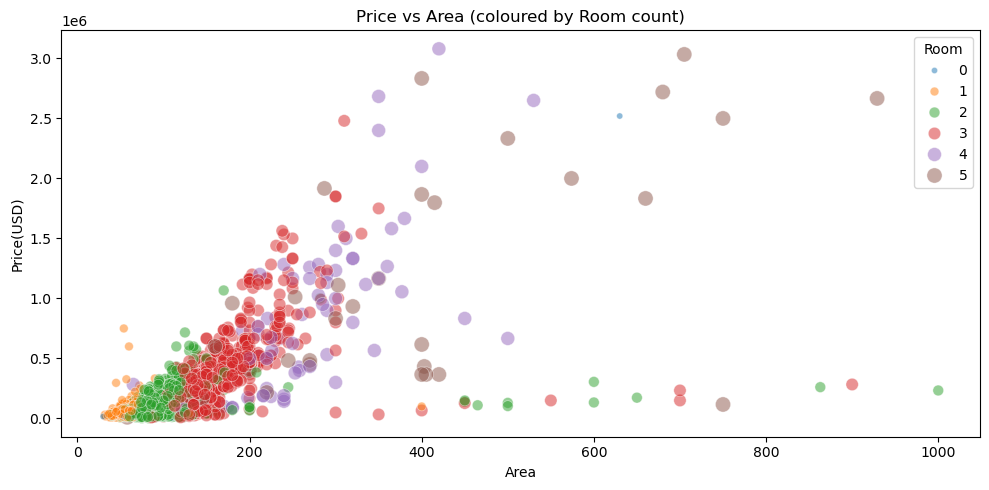

In [75]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Area', y='Price(USD)',
                hue='Room', palette='tab10', alpha=0.5,
                size='Room', sizes=(20, 120))
plt.title('Price vs Area (coloured by Room count)')
plt.tight_layout()
plt.show()

## 6. Feature Engineering

### 6.1 One-Hot Encode Address

In [76]:
df_final = pd.get_dummies(df, columns=['Address'], drop_first=True)
print(f"Shape after encoding: {df_final.shape}")
df_final.head()

Shape after encoding: (3450, 197)


,Area,Room,Parking,Warehouse,Elevator,Price(USD),Address_Abbasabad,Address_Absard,Address_Abuzar,Address_Afsarieh,...,Address_Waterfall,Address_West Ferdows Boulevard,Address_West Pars,Address_Yaftabad,Address_Yakhchiabad,Address_Yousef Abad,Address_Zafar,Address_Zaferanieh,Address_Zargandeh,Address_Zibadasht
0,63,1,1,1,1,61666.67,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,60,1,1,1,1,61666.67,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,79,2,1,1,1,18333.33,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,95,2,1,1,1,30083.33,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,123,2,1,1,1,233333.33,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### 6.2 Feature / Target Split

In [77]:
X = df_final.drop('Price(USD)', axis=1)
y = df_final['Price(USD)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (2760, 196)  |  Test: (690, 196)


## 7. Model Building & Evaluation

### 7.1 Model Configs & Param Grids

Six models: **RF**, **GB**, **XGB**, **ET**, **KNN**, **Bagging**

In [ ]:
MODEL_CONFIGS = {
    'Random Forest': {
        'estimator': RandomForestRegressor(random_state=42),
        'params': {'n_estimators': [400]},
    },
    'XGBoost': {
        'estimator': XGBRegressor(random_state=42),
        'params': {'n_estimators': [300]},
    },
    'Extra Trees': {
        'estimator': ExtraTreesRegressor(random_state=42),
        'params': {'n_estimators': [400]},
    },
    'Bagging': {
        'estimator': BaggingRegressor(random_state=42),
        'params': {'n_estimators': [400]},
    },
    'CatBoostRegressor': {
        'estimator': CatBoostRegressor(random_state=42),
        'params': {'iterations': [1000]},
    }
}

### 7.2 Train with GridSearchCV (5-Fold CV)

In [79]:
results = {}

for name, cfg in MODEL_CONFIGS.items():
    t0 = time.time()

    gs = GridSearchCV(
        estimator=cfg['estimator'],
        param_grid=cfg['params'],
        cv=5,
        scoring='r2',
        n_jobs=-1,
    )
    gs.fit(X_train, y_train)

    best = gs.best_estimator_
    y_pred = best.predict(X_test)

    results[name] = {
        'Best Params':  gs.best_params_,
        'CV R²':        gs.best_score_,
        'Test R²':      r2_score(y_test, y_pred),
        'RMSE':         np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE':          mean_absolute_error(y_test, y_pred),
        'Time (s)':     round(time.time() - t0, 1),
        'model':        best,
    }

    print(
        f"{'Model:'} {name:<20} | "
        f"CV R²={gs.best_score_:.4f} | "
        f"Test R²={r2_score(y_test, y_pred):.4f} | "
        f"{round(time.time()-t0,1)}s"
    )
    print(f"  Best Params: {gs.best_params_}\n")

Model: Random Forest        | CV R²=0.7121 | Test R²=0.7666 | 9.8s
  Best Params: {'n_estimators': 400}

Model: Gradient Boosting    | CV R²=0.6643 | Test R²=0.7290 | 3.4s
  Best Params: {'n_estimators': 400}

Model: XGBoost              | CV R²=0.7148 | Test R²=0.7681 | 6.7s
  Best Params: {'n_estimators': 300}

Model: Extra Trees          | CV R²=0.7429 | Test R²=0.7850 | 15.6s
  Best Params: {'n_estimators': 400}

Model: Bagging              | CV R²=0.7121 | Test R²=0.7658 | 11.8s
  Best Params: {'n_estimators': 400}

Learning rate set to 0.046401
0:	learn: 270301.2492386	total: 1.25ms	remaining: 1.25s
1:	learn: 263566.0622610	total: 2.18ms	remaining: 1.09s
2:	learn: 256447.3649273	total: 2.96ms	remaining: 982ms
3:	learn: 249839.9786325	total: 3.65ms	remaining: 910ms
4:	learn: 243866.1175243	total: 4.42ms	remaining: 880ms
5:	learn: 237716.1843990	total: 5.14ms	remaining: 852ms
6:	learn: 232255.7903951	total: 5.86ms	remaining: 831ms
7:	learn: 227265.6181063	total: 6.99ms	remaining: 8

### 7.3 Model Comparison Table

In [80]:
metrics_df = pd.DataFrame(
    {k: {m: v[m] for m in ['CV R²', 'Test R²', 'RMSE', 'MAE', 'Time (s)']}
     for k, v in results.items()}
).T.sort_values('Test R²', ascending=False)

metrics_df[['CV R²','Test R²']] = metrics_df[['CV R²','Test R²']].astype(float).round(4)
metrics_df[['RMSE','MAE']]       = metrics_df[['RMSE','MAE']].astype(float).round(0)

metrics_df.style.background_gradient(cmap='RdYlGn', subset=['CV R²','Test R²']) \
                .background_gradient(cmap='RdYlGn_r', subset=['RMSE','MAE'])

,CV R²,Test R²,RMSE,MAE,Time (s)
CatBoostRegressor,0.736800,0.800300,122870.000000,49081.000000,5.800000
Extra Trees,0.742900,0.785000,127473.000000,49165.000000,15.600000
XGBoost,0.714800,0.768100,132382.000000,49902.000000,6.700000
Random Forest,0.712100,0.766600,132828.000000,52494.000000,9.800000
Bagging,0.712100,0.765800,133053.000000,52539.000000,11.800000
Gradient Boosting,0.664300,0.729000,143113.000000,54732.000000,3.400000


### 7.4 Visual Comparison

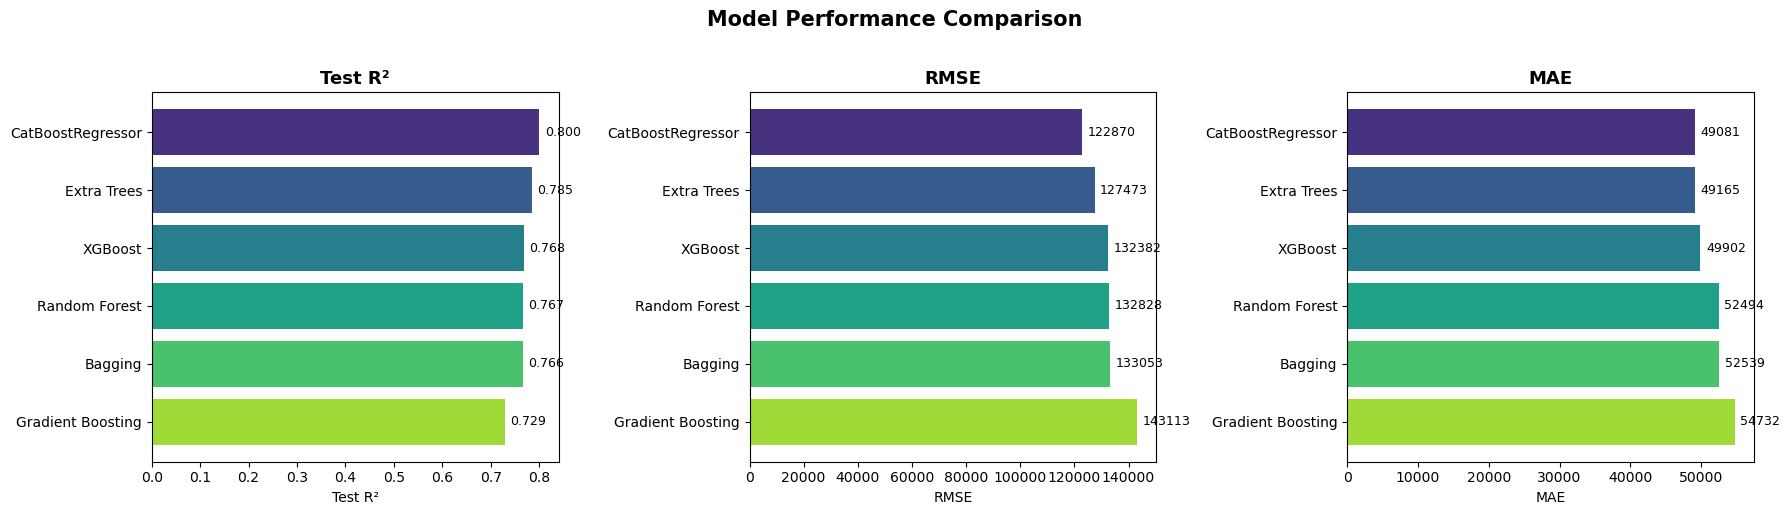

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = sns.color_palette('viridis', len(metrics_df))

for ax, metric in zip(axes, ['Test R²', 'RMSE', 'MAE']):
    ascending = (metric != 'Test R²')
    data = metrics_df[metric].astype(float).sort_values(ascending=ascending)
    bars = ax.barh(data.index, data.values, color=palette)
    ax.bar_label(bars, fmt='%.3f' if metric == 'Test R²' else '%.0f', padding=4, fontsize=9)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel(metric)
    ax.invert_yaxis()

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.5 CV R² vs Test R² (Overfitting Check)

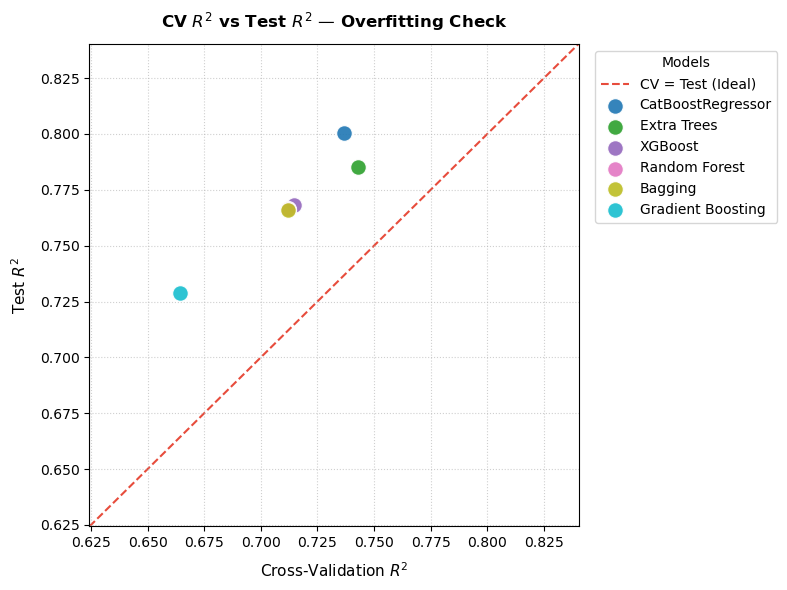

In [82]:
fig, ax = plt.subplots(figsize=(8, 6))

# Ensure data types are correct
cv_r2   = metrics_df['CV R²'].astype(float)
test_r2 = metrics_df['Test R²'].astype(float)

# Dynamic axis limits
min_val = max(0, min(cv_r2.min(), test_r2.min())) - 0.04
max_val = min(1.0, max(cv_r2.max(), test_r2.max())) + 0.04
lim = [min_val, max_val]

# Plot the ideal line in the background
ax.plot(lim, lim, color='#e74c3c', linestyle='--', linewidth=1.5, label='CV = Test (Ideal)', zorder=1)

# Plot each model individually to generate distinct colors for the legend box
colors = plt.cm.get_cmap('tab10', len(metrics_df))

for i, (name, cv, test) in enumerate(zip(metrics_df.index, cv_r2, test_r2)):
    ax.scatter(cv, test, color=colors(i), s=130, alpha=0.9, edgecolors='w', linewidth=1, label=name, zorder=3)

# Formatting and Layout
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel('Cross-Validation $R^2$', fontsize=11, labelpad=8)
ax.set_ylabel('Test $R^2$', fontsize=11, labelpad=8)
ax.set_title('CV $R^2$ vs Test $R^2$ — Overfitting Check', fontsize=12, pad=12, fontweight='bold')

# Place the box in the upper-left (or lower-right) corner
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, shadow=False, title="Models")
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### 7.6 Model

In [83]:
# Define the parameter grid for tuning CatBoost
param_grid = {
    'iterations': [300],
    'learning_rate': [0.05, 0.1],
    'depth': [4, 7, 10],
    'l2_leaf_reg': [1, 3, 5]
}

# Set up the GridSearchCV with CatBoostRegressor
grid_search = GridSearchCV(
    estimator=CatBoostRegressor(random_state=42, verbose=0),
    param_grid=param_grid,
    cv=5,              # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1          # Use all available CPU cores
)

# Run the grid search
grid_search.fit(X_train, y_train)

,estimator,"CatBoostRegre...42, verbose=0)"
,param_grid,"{'depth': [4, 7, ...], 'iterations': [300], 'l2_leaf_reg': [1, 3, ...], 'learning_rate': [0.05, 0.1]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


In [84]:
# Print out the best parameters and cross-validation score
print("Best hyperparameters found:")
print(grid_search.best_params_)
print("\nBest cross-validation accuracy: {:.2f}%".format(grid_search.best_score_ * 100))

best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print("Test set accuracy: {:.2f}%".format(test_accuracy * 100))

Best hyperparameters found:
{'depth': 10, 'iterations': 300, 'l2_leaf_reg': 5, 'learning_rate': 0.1}

Best cross-validation accuracy: 75.66%
Test set accuracy: 79.23%


In [85]:
# Predict & Evaluate
predictions = best_model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"Model Performance: \n")
print(f"Mean Squared Error: {mse:.4f}")
print("RMSE: %f" % (rmse))
print(f"R^2 Score: {r2:.4f}")

Model Performance: 

Mean Squared Error: 15697346157.3350
RMSE: 125289.050429
R^2 Score: 0.7923


### 7.7 Actual vs Predicted

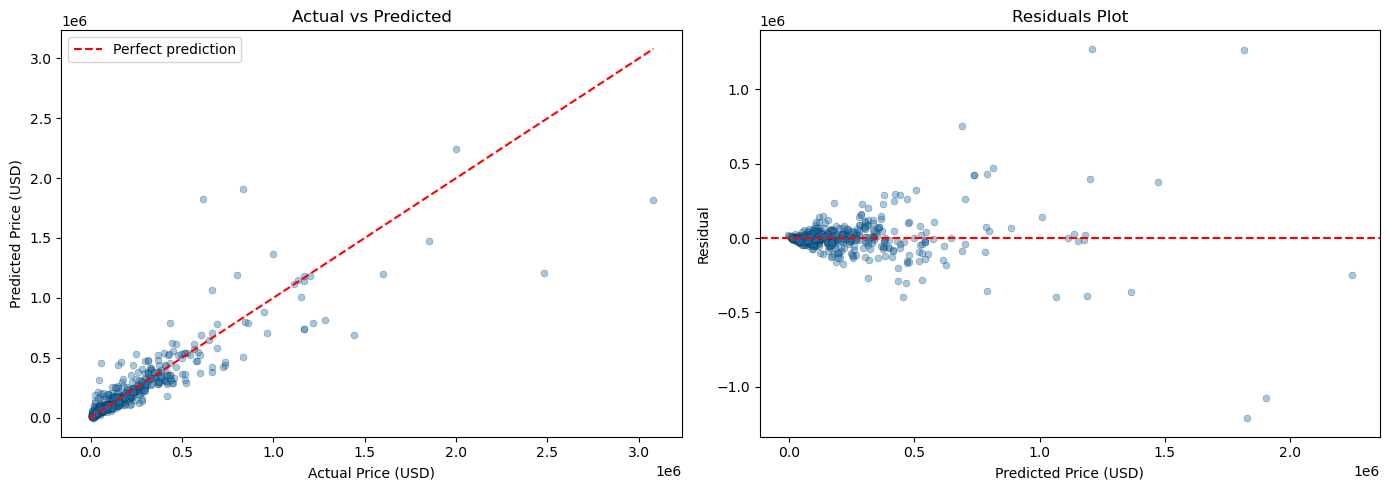

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
y_pred_best = best_model.predict(X_test)

# Scatter: Actual vs Predicted
ax = axes[0]
ax.scatter(y_test, y_pred_best, alpha=0.4, edgecolors='k', linewidths=0.3, s=25)
lim = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price (USD)'); ax.set_ylabel('Predicted Price (USD)')
ax.set_title(f'Actual vs Predicted'); ax.legend()

# Residuals
ax = axes[1]
residuals = y_test.values - y_pred_best
ax.scatter(y_pred_best, residuals, alpha=0.4, edgecolors='k', linewidths=0.3, s=25)
ax.axhline(0, color='r', linestyle='--', lw=1.5)
ax.set_xlabel('Predicted Price (USD)'); ax.set_ylabel('Residual')
ax.set_title('Residuals Plot')

plt.tight_layout(); plt.show()

### 7.8 Feature Importances

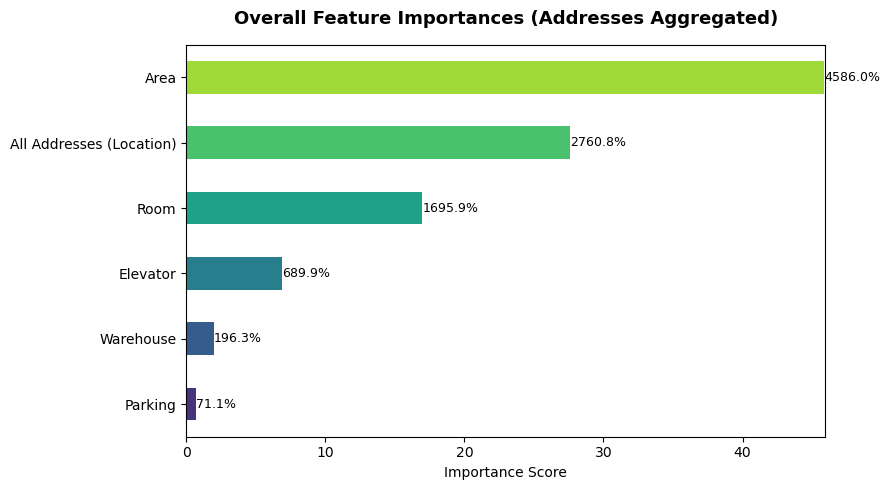

In [87]:
# Feature Importances
if hasattr(best_model, 'feature_importances_'):
    # 1. Map raw feature importances to feature names
    imp = pd.Series(best_model.feature_importances_, index=X_train.columns)
    
    # 2. Extract and sum up all one-hot encoded 'Address_' column scores
    address_mask = imp.index.str.startswith('Address_')
    total_address_importance = imp[address_mask].sum()
    
    # 3. Build a new series grouping all other numerical features + the unified Address score
    grouped_imp = imp[~address_mask].copy()
    grouped_imp['All Addresses (Location)'] = total_address_importance
    
    # Sort them for the plot
    grouped_imp = grouped_imp.sort_values(ascending=True)

    # 4. Plot the unified feature importances
    plt.figure(figsize=(9, 5))
    grouped_imp.plot.barh(color=sns.color_palette('viridis', len(grouped_imp)))
    
    # Add data labels inside/next to the bars for exact clarity
    for i, val in enumerate(grouped_imp.values):
        plt.text(val + 0.005, i, f"{val*100:.1f}%", va='center', fontsize=9, fontweight='medium')
        
    plt.title('Overall Feature Importances (Addresses Aggregated)', fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Importance Score')
    plt.xlim(0, max(grouped_imp.values) + 0.08)  # Leave room for text labels
    plt.tight_layout()
    plt.show()
else:
    print("The best model does not expose feature_importances_.")

## 8. Save Trained Model

In [88]:
# Save Trained Model
os.makedirs('saved_models', exist_ok=True)

model_filename = 'saved_models/tehran_housing_best_model.pkl'
features_filename = 'saved_models/model_features.pkl'

# Save the best model and the specific column layout
joblib.dump(best_model, model_filename)
joblib.dump(X_train.columns.tolist(), features_filename)

['saved_models/model_features.pkl']